In [1]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

baseline_dir = r"C:\Users\Lenovo\Internship\models\week2_baseline_blip"
processor = BlipProcessor.from_pretrained(baseline_dir)
model = BlipForConditionalGeneration.from_pretrained(baseline_dir).to(device)
model.eval()

print("Model loaded.")

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Model loaded.


In [2]:
!pip install lime scikit-image --quiet

import os
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from lime import lime_image
from skimage.segmentation import mark_boundaries
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

XAI_DIR = r"C:\Users\Lenovo\Internship\data\xai_examples"
OUTPUT_DIR = r"C:\Users\Lenovo\Internship\data\xai_examples\lime_overlays"
os.makedirs(OUTPUT_DIR, exist_ok=True)

smoothie = SmoothingFunction().method4

with open(os.path.join(XAI_DIR, "xai_examples_metadata.json"), "r", encoding="utf-8") as f:
    examples = json.load(f)

print(f"Loaded {len(examples)} examples")

Loaded 12 examples


In [3]:
def get_caption(image_array):
    image = Image.fromarray(image_array.astype('uint8'))
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(**inputs, num_beams=3, max_new_tokens=25)
    return processor.decode(out[0], skip_special_tokens=True)

def caption_similarity(original_caption, new_caption):
    ref = [original_caption.lower().split()]
    hyp = new_caption.lower().split()
    if len(hyp) == 0:
        return 0.0
    return sentence_bleu(ref, hyp, smoothing_function=smoothie)

In [4]:
def make_lime_predict_fn(original_caption):
    def predict_fn(images_batch):
        scores = []
        for img in images_batch:
            new_caption = get_caption(img)
            score = caption_similarity(original_caption, new_caption)
            scores.append([1 - score, score])
        return np.array(scores)
    return predict_fn

In [5]:
import time

explainer = lime_image.LimeImageExplainer()

test_ex = examples[0]
img_path = os.path.join(XAI_DIR, test_ex["image_name"])
image = Image.open(img_path).convert("RGB").resize((224, 224))
image_np = np.array(image)

start = time.time()
predict_fn = make_lime_predict_fn(test_ex["generated_caption"])
explanation = explainer.explain_instance(
    image_np, predict_fn, top_labels=1, hide_color=0, num_samples=20
)
print(f"Time for 1 image, 20 samples: {time.time() - start:.1f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Time for 1 image, 20 samples: 132.7 seconds


  0%|          | 0/20 [00:00<?, ?it/s]

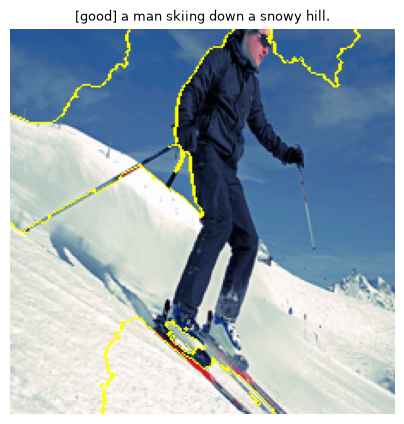

Done: 3457572788_e1fe4f6480.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

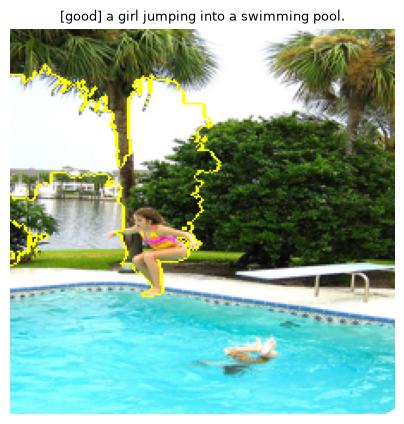

Done: 2795287622_da187a3e86.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

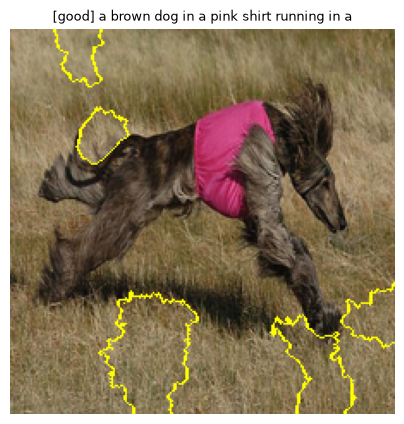

Done: 977856234_0d9caee7b2.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

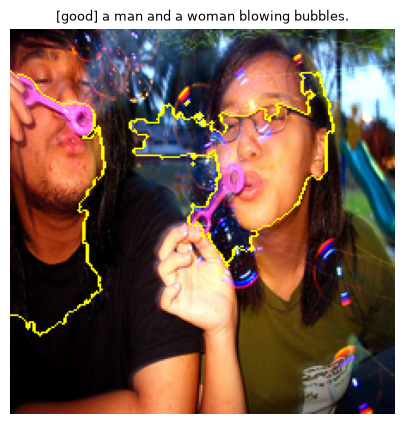

Done: 197142902_f05ff198c2.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

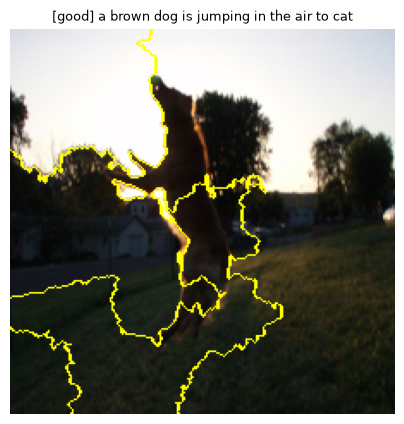

Done: 162743064_bb242faa31.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

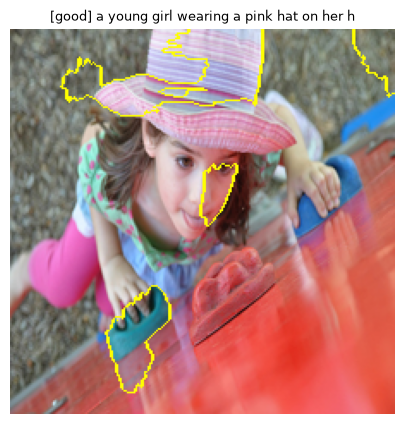

Done: 3475581086_a533567561.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

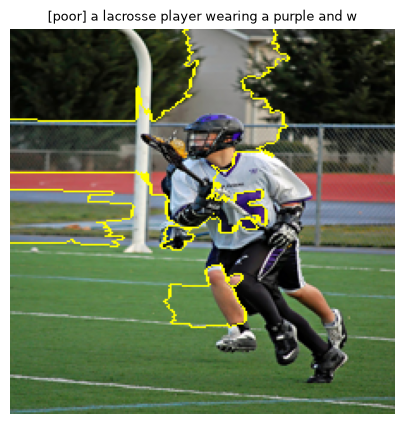

Done: 3364160101_c5e6c52b25.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

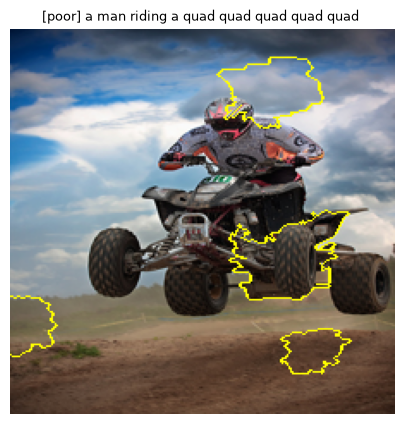

Done: 3560081723_62da0035bd.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

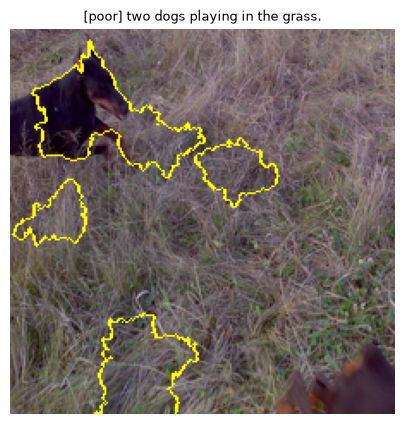

Done: 1598085252_f3219b6140.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

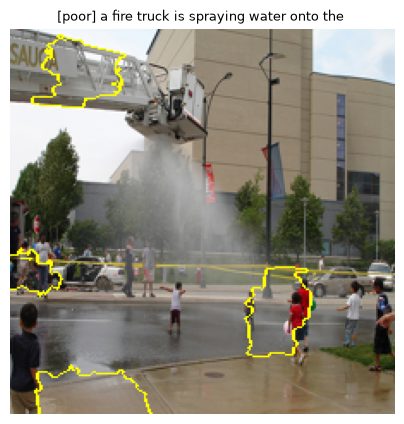

Done: 181103691_fb2f956abd.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

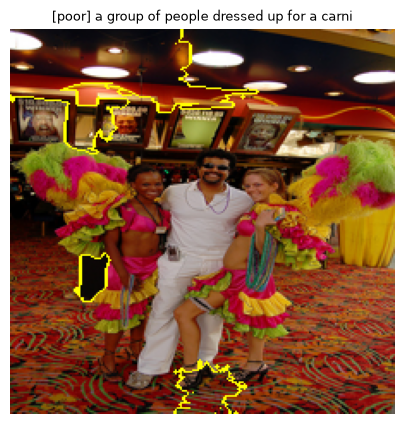

Done: 3084034954_fe5737197d.jpg


  0%|          | 0/20 [00:00<?, ?it/s]

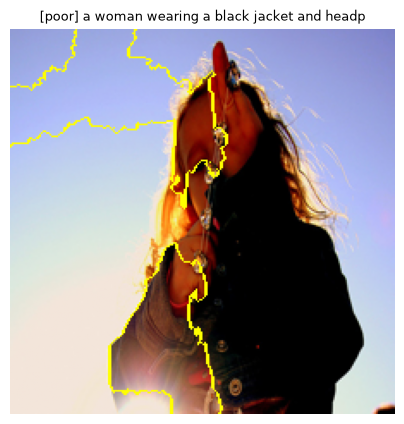

Done: 1564614124_0ee6799935.jpg

LIME processing complete.
[{'image_name': '3457572788_e1fe4f6480.jpg', 'status': 'success'}, {'image_name': '2795287622_da187a3e86.jpg', 'status': 'success'}, {'image_name': '977856234_0d9caee7b2.jpg', 'status': 'success'}, {'image_name': '197142902_f05ff198c2.jpg', 'status': 'success'}, {'image_name': '162743064_bb242faa31.jpg', 'status': 'success'}, {'image_name': '3475581086_a533567561.jpg', 'status': 'success'}, {'image_name': '3364160101_c5e6c52b25.jpg', 'status': 'success'}, {'image_name': '3560081723_62da0035bd.jpg', 'status': 'success'}, {'image_name': '1598085252_f3219b6140.jpg', 'status': 'success'}, {'image_name': '181103691_fb2f956abd.jpg', 'status': 'success'}, {'image_name': '3084034954_fe5737197d.jpg', 'status': 'success'}, {'image_name': '1564614124_0ee6799935.jpg', 'status': 'success'}]


In [6]:
lime_results = []

for ex in examples:
    img_path = os.path.join(XAI_DIR, ex["image_name"])
    original_caption = ex["generated_caption"]

    image = Image.open(img_path).convert("RGB").resize((224, 224))
    image_np = np.array(image)

    predict_fn = make_lime_predict_fn(original_caption)

    try:
        explanation = explainer.explain_instance(
            image_np,
            predict_fn,
            top_labels=1,
            hide_color=0,
            num_samples=20
        )

        temp, mask = explanation.get_image_and_mask(
            explanation.top_labels[0],
            positive_only=True,
            num_features=5,
            hide_rest=False
        )

        overlay = mark_boundaries(temp / 255.0, mask)

        plt.figure(figsize=(5, 5))
        plt.imshow(overlay)
        plt.title(f"[{ex['quality_label']}] {original_caption[:40]}", fontsize=9)
        plt.axis("off")

        out_path = os.path.join(OUTPUT_DIR, f"lime_{ex['image_name']}")
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.show()

        lime_results.append({"image_name": ex["image_name"], "status": "success"})
        print(f"Done: {ex['image_name']}")

    except Exception as e:
        print(f"Failed on {ex['image_name']}: {e}")
        lime_results.append({"image_name": ex["image_name"], "status": f"failed: {e}"})

print("\nLIME processing complete.")
print(lime_results)

In [7]:
with open(os.path.join(OUTPUT_DIR, "lime_results_summary.json"), "w") as f:
    json.dump(lime_results, f, indent=2)

print("Saved summary.")

Saved summary.


In [8]:
import os
lime_files = [f for f in os.listdir(OUTPUT_DIR) if f.startswith("lime_")]
print("LIME overlays saved:", len(lime_files))
print(lime_files)

LIME overlays saved: 13
['lime_1564614124_0ee6799935.jpg', 'lime_1598085252_f3219b6140.jpg', 'lime_162743064_bb242faa31.jpg', 'lime_181103691_fb2f956abd.jpg', 'lime_197142902_f05ff198c2.jpg', 'lime_2795287622_da187a3e86.jpg', 'lime_3084034954_fe5737197d.jpg', 'lime_3364160101_c5e6c52b25.jpg', 'lime_3457572788_e1fe4f6480.jpg', 'lime_3475581086_a533567561.jpg', 'lime_3560081723_62da0035bd.jpg', 'lime_977856234_0d9caee7b2.jpg', 'lime_results_summary.json']


In [9]:
lime_images = [f for f in lime_files if f.endswith(".jpg") or f.endswith(".png")]
print("LIME image overlays:", len(lime_images))

LIME image overlays: 12
